## Model

### Architecture

- Input: 28*28 array of pixel intensities of each image.
- Output: 10 classes (digits: 0 to 9).
- Activation function: Softmax activation.
- Loss function: Sparse categorical cross entropy.

In [1]:
import keras
from keras import layers
from keras import Sequential
from keras.layers import Dense

In [2]:
model = keras.Sequential()
model.add(keras.Input(shape=(784,)))
# Add a single neuron.
model.add(Dense(10, activation="softmax"))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

### Compile the model

In [3]:
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

### Train the model

(50000, 28, 28)
(10000, 28, 28)
(10000, 28, 28)
1


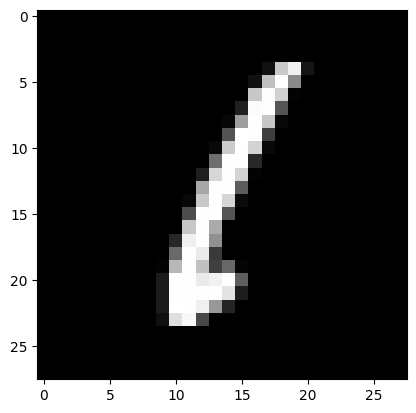

(50000, 784)
(10000, 784)
(10000, 784)


In [4]:
%run -i data_retrieval.ipynb

In [5]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=128,
    verbose=False,
    validation_data=(X_val, y_val),
)

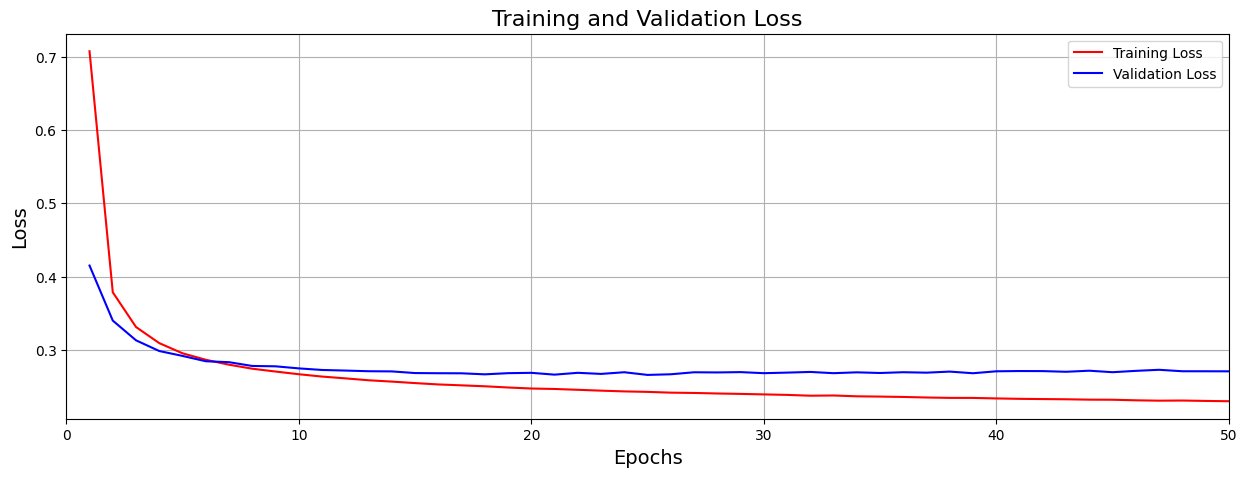

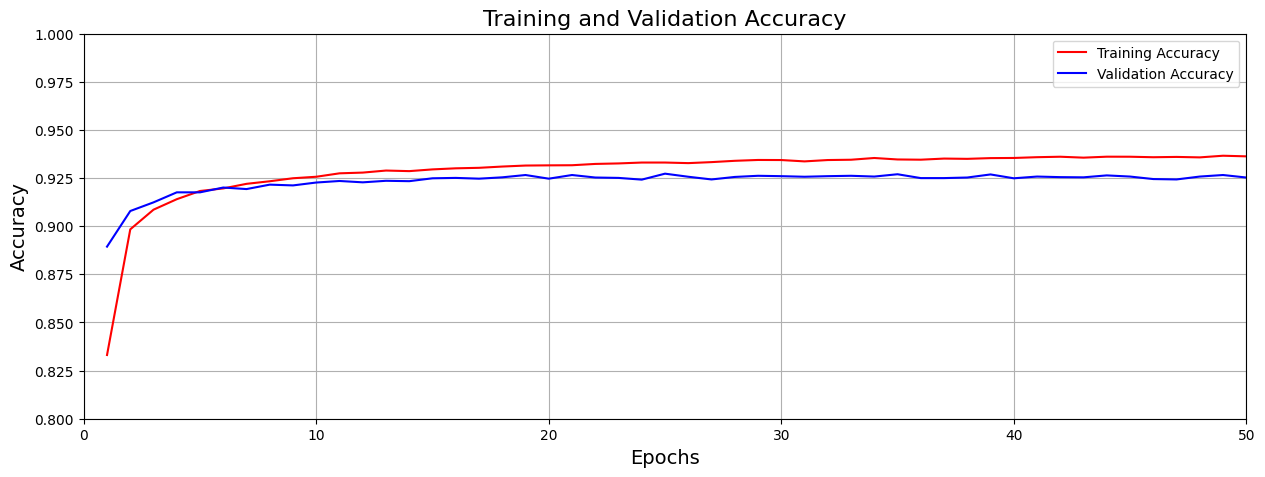

In [6]:
history_dict = history.history
loss_values = history_dict["loss"]
validation_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)

plt.figure(figsize=[15, 5])
plt.plot(epochs, loss_values, "r", label="Training Loss")
plt.plot(epochs, validation_loss_values, "b", label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.xlim(0, len(loss_values))
plt.legend()
plt.grid()
plt.show()

accuracy_values = history_dict["accuracy"]
validation_accuracy_values = history_dict["val_accuracy"]
plt.figure(figsize=[15, 5])
plt.plot(epochs, accuracy_values, "r", label="Training Accuracy")
plt.plot(epochs, validation_accuracy_values, "b", label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.xlim(0, len(loss_values))
plt.ylim(0.8, 1.0)
plt.legend()
plt.grid()
plt.show()

#### Observations:
- Validation Loss plot flattens out after around 10 epochs
- While the Validation loss flattens out, the train loss continues to decline. This is an indication that the model is over-fitting the training data.
- Validation accuracy plot flattens out at around 92.5%

### Save the model

The trained model can be saved using the `.save()` method on the model, which will save the model to the file system in the 'SavedModel' format. This method creates a folder on the file system. Within this folder, the model architecture and training configuration (including the optimizer, losses, and metrics) are stored in saved_model.pb. The 'variables/' folder contains a standard training checkpoint that includes the weights of the model.

In [7]:
model.save("MNIST_classification_model.keras")